In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
import zarr
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')

In [48]:
directory = mypass / "beads1um" / "20260707" / "beads1um_crop"
MTs_path = directory / "MTs_im_theta.zarr"
beads_path = directory / "beads_tracks.csv"

MTs = zarr.open_array(MTs_path, mode='r')
beads = pd.read_csv(beads_path)

theta = np.nanmean(MTs, axis = (1,2))

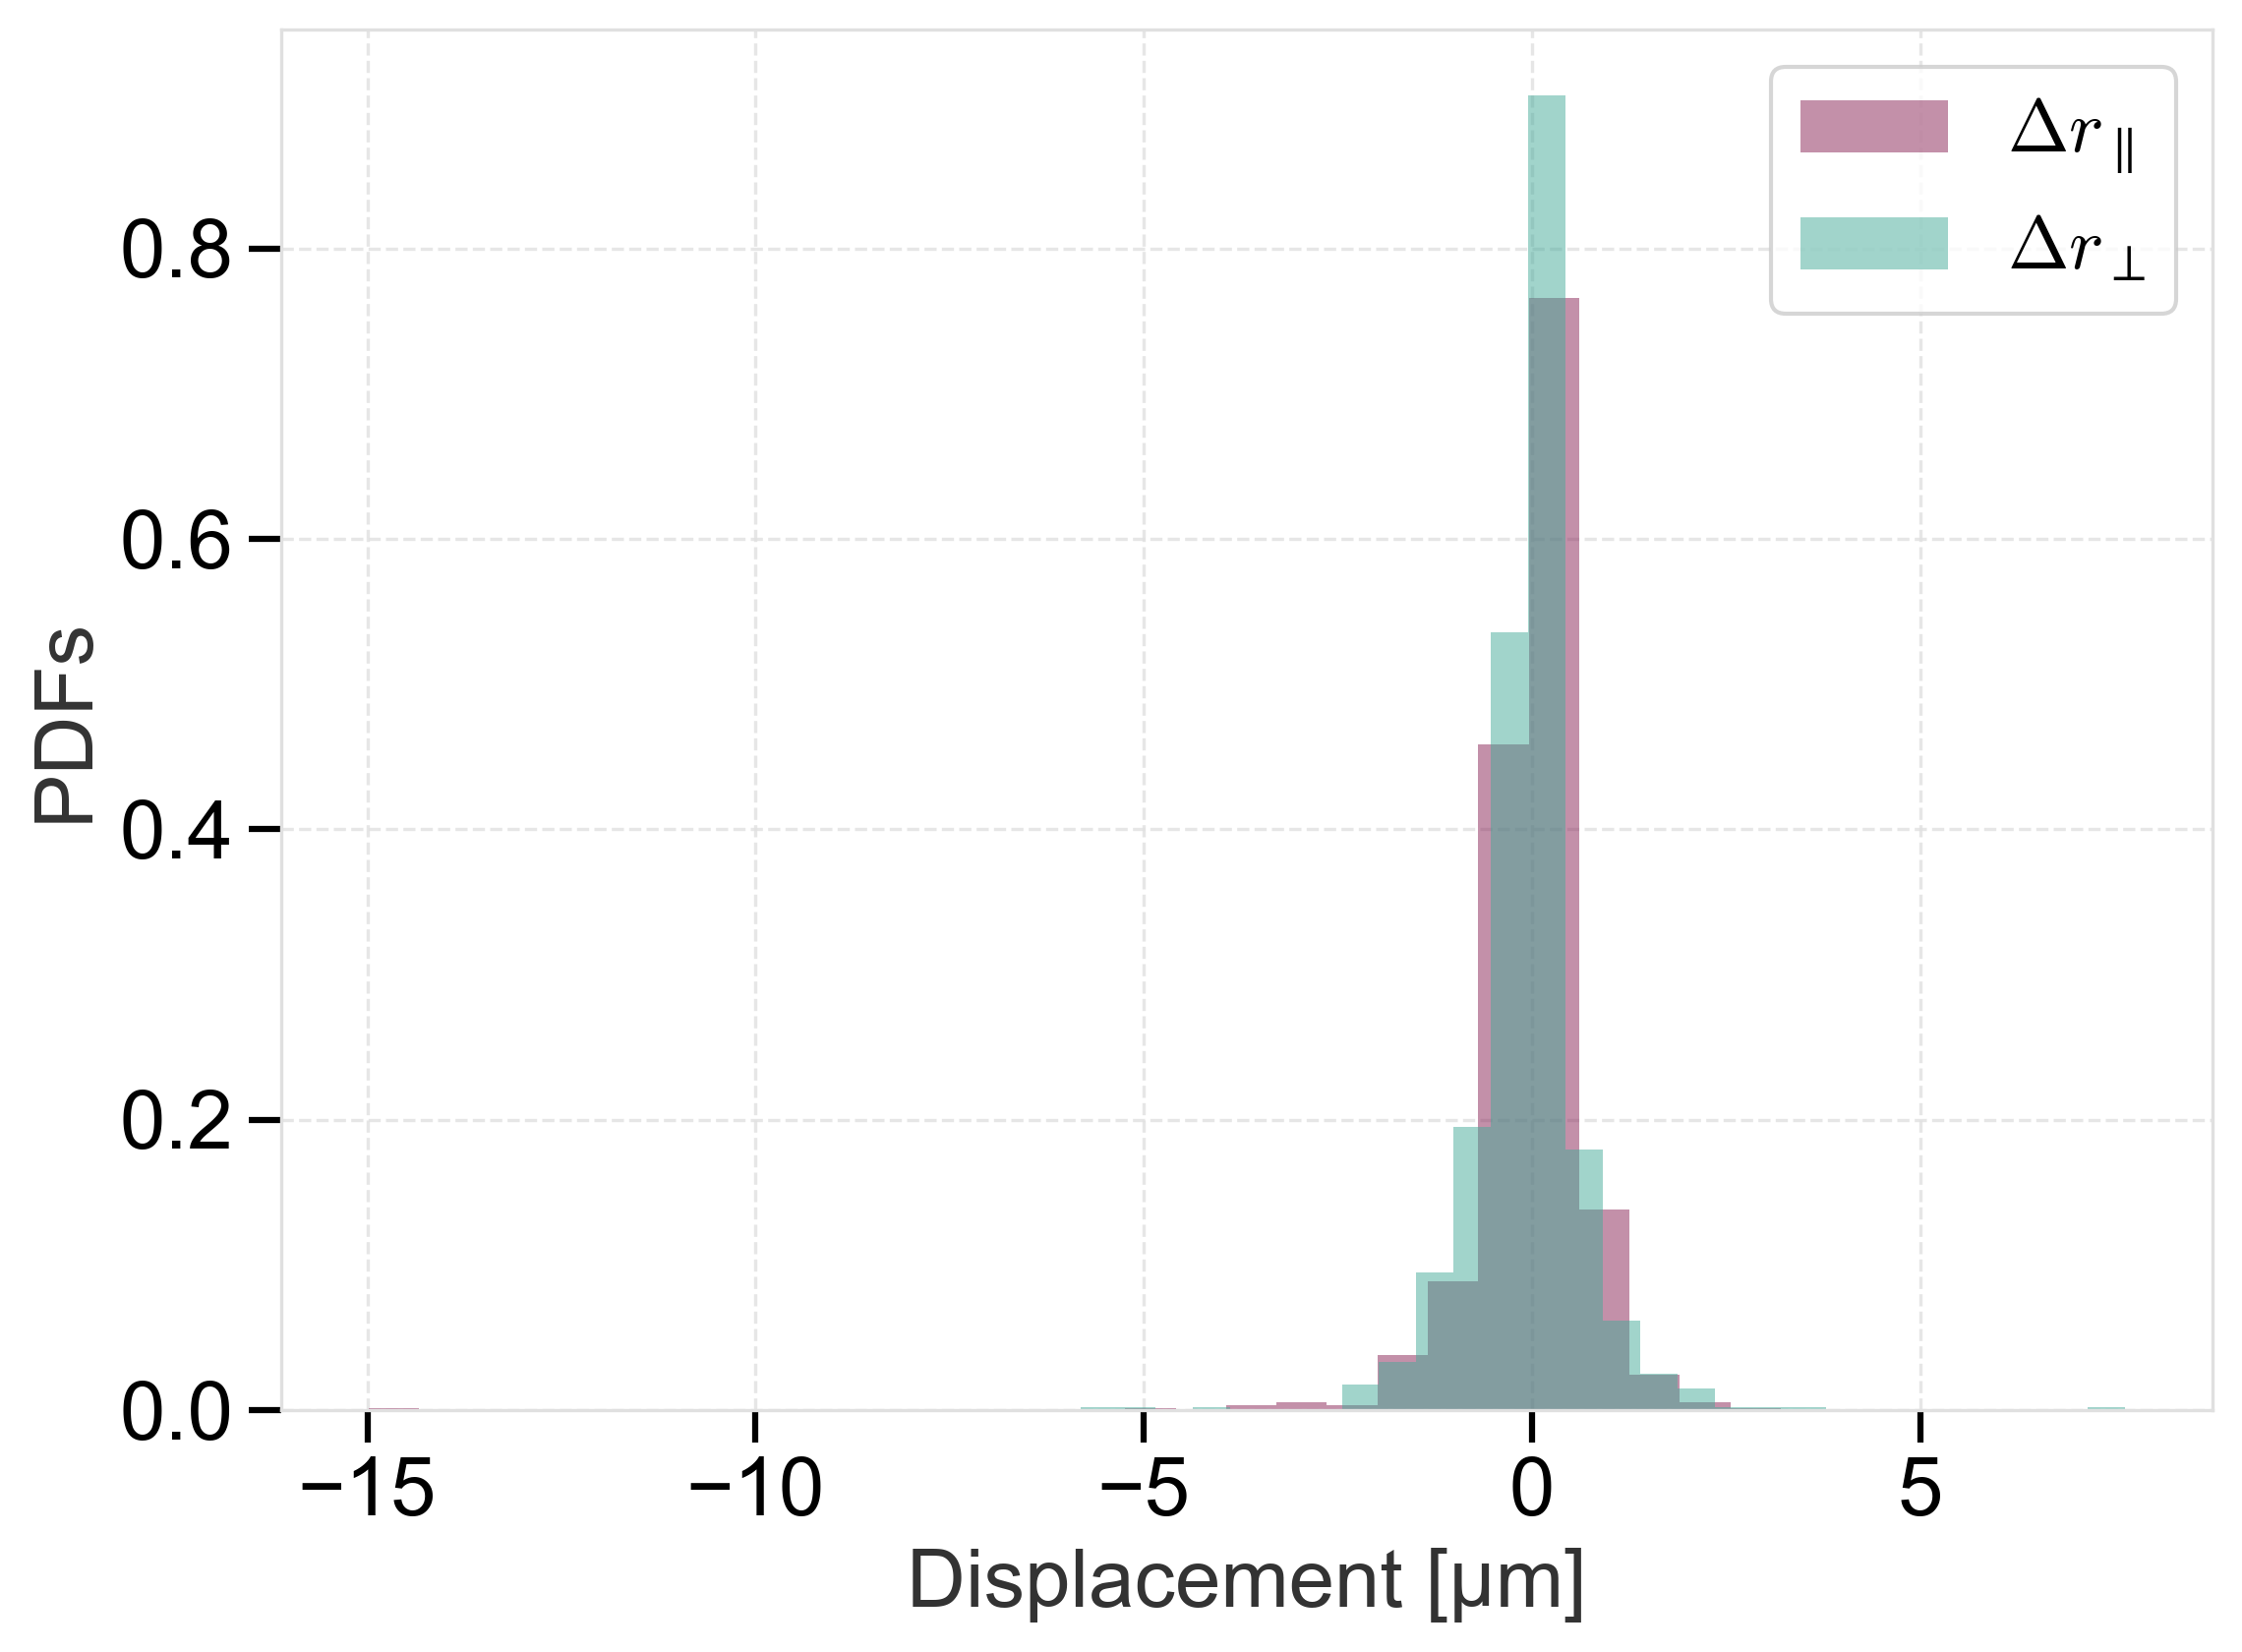

In [52]:
TAU = 4
SCALE = 0.11
INTERVAL = 4
tau_frame = int(TAU/INTERVAL)

# Calculate PDF taking theta as the primary axis (parallel) and secondary axis (perpendicular)
PDF_parallel = dpm.PDF_theta(beads, tau_frame, theta, scale=SCALE, component='parallel')
PDF_perpendicular = dpm.PDF_theta(beads, tau_frame, theta, scale=SCALE, component='perpendicular')

fig, ax = plt.subplots()
bins_para = np.histogram_bin_edges(PDF_parallel, bins='sqrt')
bins_perp = np.histogram_bin_edges(PDF_perpendicular, bins='sqrt')
ax.hist(PDF_parallel, bins=bins_para[:-1], alpha=0.5, label='$\\Delta r_{\\parallel}$', color = style_colors[0], density=True)
ax.hist(PDF_perpendicular, bins=bins_perp[:-1], alpha=0.5, label='$\\Delta r_{\\perp}$', color = style_colors[5], density=True)
ax.set_xlabel('Displacement [\u03bcm]')
ax.set_ylabel('PDFs')
ax.legend()
plt.show()